<a href="https://colab.research.google.com/github/Akshayus29/Assignments/blob/main/casestudy_unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score
from sklearn.naive_bayes import GaussianNB #NB
from sklearn.tree import DecisionTreeClassifier #DT
from sklearn.svm import SVC #SVM
from sklearn.model_selection import GridSearchCV #model fine tuning
from sklearn.ensemble import RandomForestClassifier  # Model Feature Selection
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram,linkage
from sklearn.cluster import AgglomerativeClustering

## 1.Data Preproccessing

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
from google.colab import drive
drive.mount('/content/drive')

filepath ='/content/drive/MyDrive/DSA folder/Data/adult_dataset.csv'
adult_df = pd.read_csv(filepath)
adult_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [6]:
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [7]:
adult_df.duplicated().sum()


np.int64(16)

In [8]:
adult_df.drop_duplicates(inplace=True)

In [9]:
adult_df.duplicated().sum()

np.int64(0)

In [10]:
adult_df.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [11]:
cat_cols = adult_df.select_dtypes(include=['object']).columns

for col in cat_cols:
  print(f'\ncolumn name: {col}')
  print(adult_df[col].value_counts(dropna=False))

print('categorical columns: \n',cat_cols)


column name: workclass
workclass
Private             32205
Self-emp-not-inc     3649
NaN                  3362
Local-gov            2973
State-gov            1877
?                    1763
Self-emp-inc         1624
Federal-gov          1346
Without-pay            18
Never-worked            9
Name: count, dtype: int64

column name: education
education
HS-grad         15780
Some-college    10874
Bachelors        8021
Masters          2657
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              656
Doctorate         594
5th-6th           508
1st-4th           246
Preschool          83
Name: count, dtype: int64

column name: marital-status
marital-status
Married-civ-spouse       22377
Never-married            16105
Divorced                  6631
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: c

In [12]:
for col in ['workclass', 'occupation', 'native-country']:
  adult_df[col] = adult_df[col].replace('?', np.nan)

In [13]:
# Categorical: Fill with Mode
cat_cols = ['workclass', 'occupation', 'native-country']
for col in cat_cols:
    adult_df[col] = adult_df[col].fillna(adult_df[col].mode()[0])

In [14]:
# Numerical: Fill with Median
num_cols = ['age', 'hours-per-week']
for col in num_cols:
    adult_df[col] = adult_df[col].fillna(adult_df[col].median())

In [15]:
adult_df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


,0
age,"Axes(0.125,0.53;0.168478x0.35)"
fnlwgt,"Axes(0.327174,0.53;0.168478x0.35)"
education-num,"Axes(0.529348,0.53;0.168478x0.35)"
capital-gain,"Axes(0.731522,0.53;0.168478x0.35)"
capital-loss,"Axes(0.125,0.11;0.168478x0.35)"
hours-per-week,"Axes(0.327174,0.11;0.168478x0.35)"


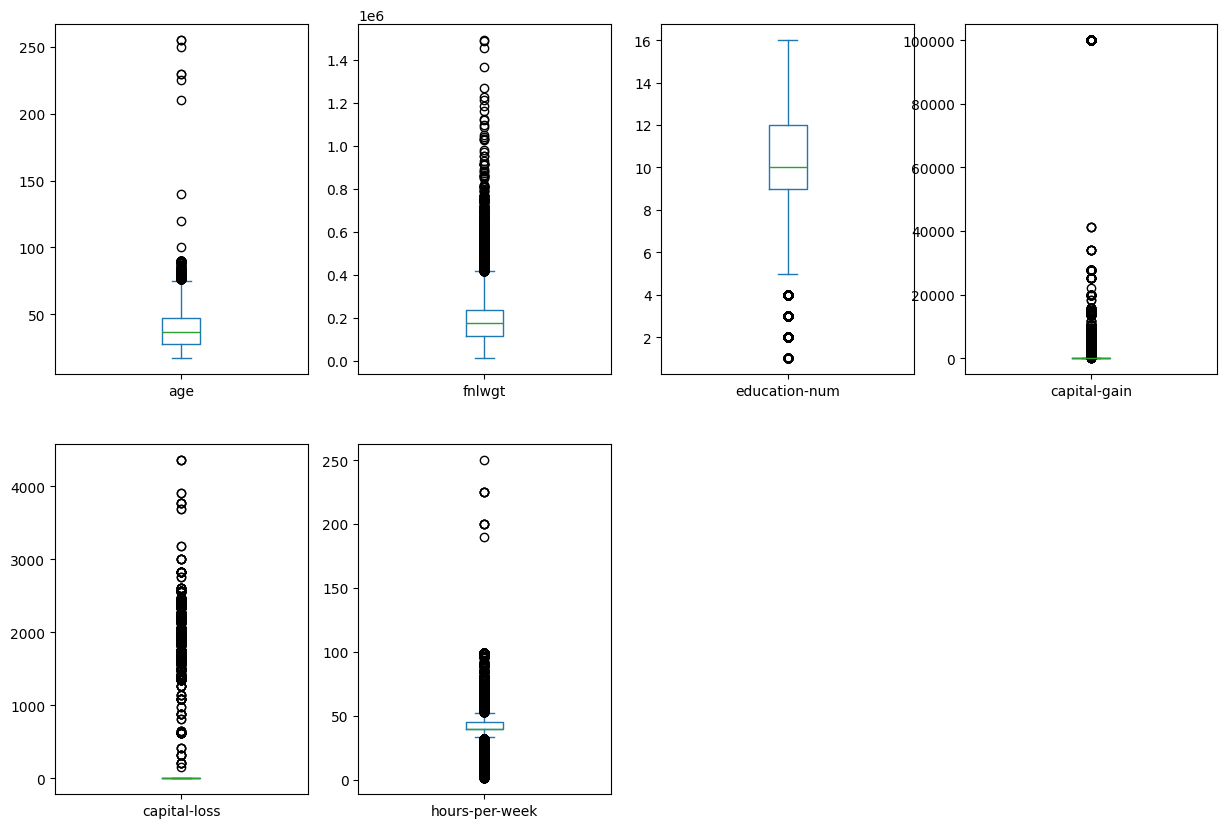

In [16]:
adult_df.plot(kind='box', subplots=True, layout=(2, 4), figsize=(15, 10))

In [17]:
num_cols = adult_df.select_dtypes(include=['int64', 'float64']).columns


for col in num_cols:
    Q1 = adult_df[col].quantile(0.25)
    Q3 = adult_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    adult_df[col] = np.clip(adult_df[col], lower, upper)

,0
age,"Axes(0.125,0.53;0.168478x0.35)"
fnlwgt,"Axes(0.327174,0.53;0.168478x0.35)"
education-num,"Axes(0.529348,0.53;0.168478x0.35)"
capital-gain,"Axes(0.731522,0.53;0.168478x0.35)"
capital-loss,"Axes(0.125,0.11;0.168478x0.35)"
hours-per-week,"Axes(0.327174,0.11;0.168478x0.35)"


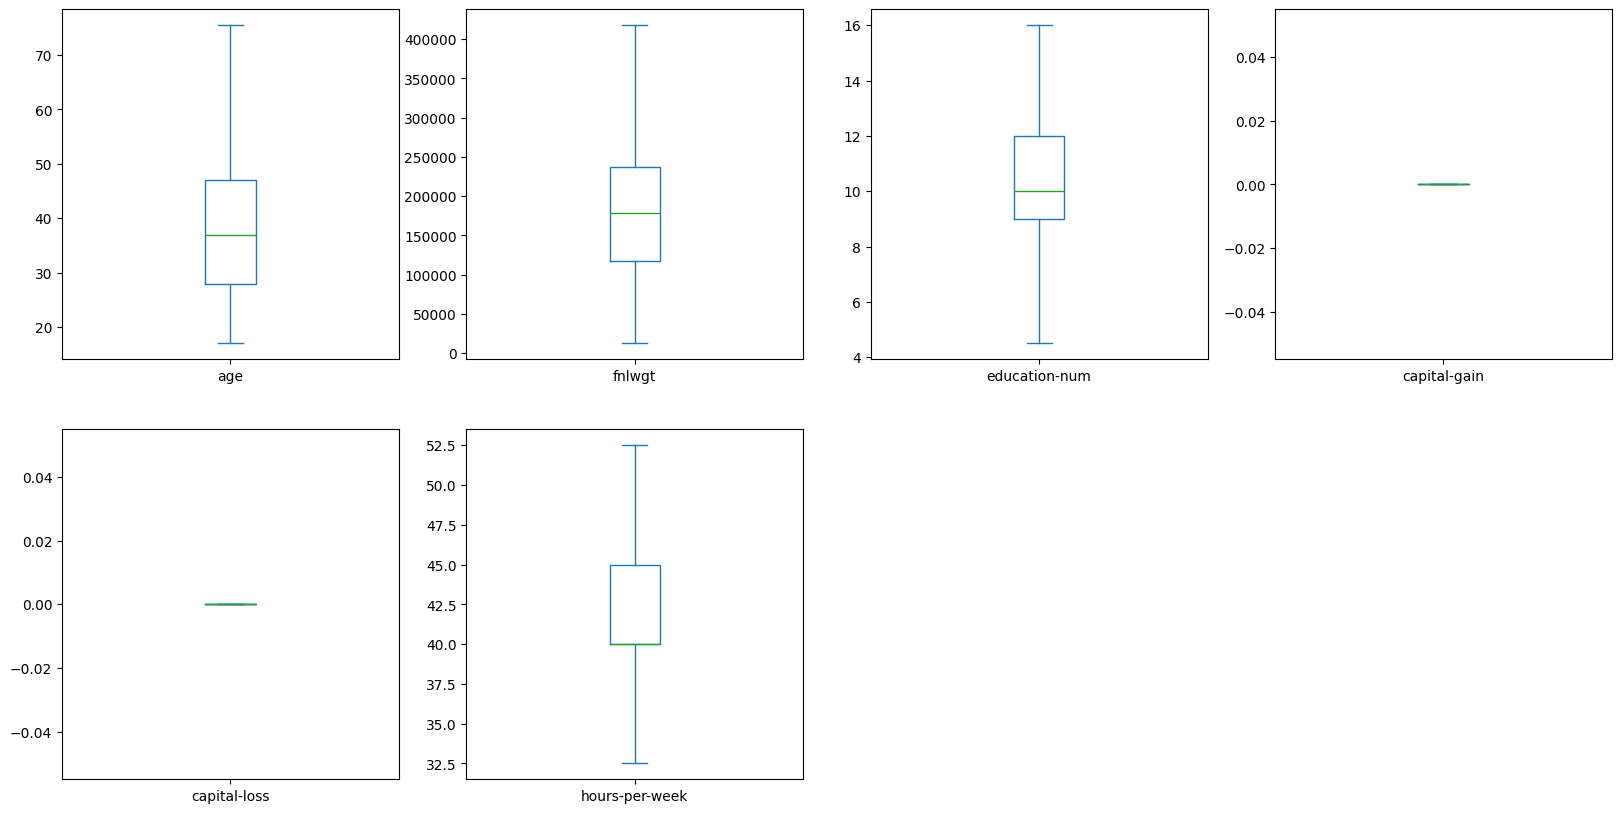

In [18]:
adult_df.plot(kind='box', subplots=True, layout=(2, 4), figsize=(20, 10))

In [10]:
# Label Encoding for clustering efficiency
le = LabelEncoder()
adult_df_encoded = adult_df.copy()
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

for col in categorical_features:
    adult_df_encoded[col] = le.fit_transform(adult_df_encoded[col].astype(str))

In [20]:
adult_df_encoded.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,6,77516,9,13.0,4,0,1,4,1,0,0,40.0,38,<=50K
1,50.0,5,83311,9,13.0,2,3,0,4,1,0,0,32.5,38,<=50K
2,38.0,3,215646,11,9.0,0,5,1,4,1,0,0,40.0,38,<=50K
3,53.0,3,234721,1,7.0,2,5,0,2,1,0,0,40.0,38,<=50K
4,28.0,3,338409,9,13.0,2,9,5,2,0,0,0,40.0,4,<=50K


In [11]:
# Scaling (StandardScaler is crucial for KMeans)
features = adult_df_encoded.drop('income', axis=1)
scaler = StandardScaler()
adult_df_scaled = scaler.fit_transform(features)

In [12]:
adult_df_scaled = pd.DataFrame(adult_df_scaled, columns=features.columns)
adult_df_scaled.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0.022998,1.469968,-1.061979,-0.332542,1.136512,0.916138,-1.384693,-0.276685,0.392384,0.70422,0.146932,-0.217127,-0.035471,0.663764
1,0.811370,0.926613,-1.007104,-0.332542,1.136512,-0.410397,-0.723408,-0.900852,0.392384,0.70422,-0.144804,-0.217127,-2.170389,0.246314
2,-0.048672,-0.160096,0.246034,0.183660,-0.419335,-1.736932,-0.282551,-0.276685,0.392384,0.70422,-0.144804,-0.217127,-0.035471,0.246314
3,1.026380,-0.160096,0.426663,-2.397350,-1.197259,-0.410397,-0.282551,-0.900852,-1.971746,0.70422,-0.144804,-0.217127,-0.035471,0.246314
4,-0.765374,-0.160096,1.408530,-0.332542,1.136512,-0.410397,0.599162,2.219984,-1.971746,-1.42001,-0.144804,-0.217127,-0.035471,-4.484780


In [23]:
adult_df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48826 entries, 0 to 48825
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48826 non-null  float64
 1   workclass       48826 non-null  float64
 2   fnlwgt          48826 non-null  float64
 3   education       48826 non-null  float64
 4   education-num   48826 non-null  float64
 5   marital-status  48826 non-null  float64
 6   occupation      48826 non-null  float64
 7   relationship    48826 non-null  float64
 8   race            48826 non-null  float64
 9   sex             48826 non-null  float64
 10  capital-gain    48826 non-null  float64
 11  capital-loss    48826 non-null  float64
 12  hours-per-week  48826 non-null  float64
 13  native-country  48826 non-null  float64
dtypes: float64(14)
memory usage: 5.2 MB


## 2.Exploratory Analysis

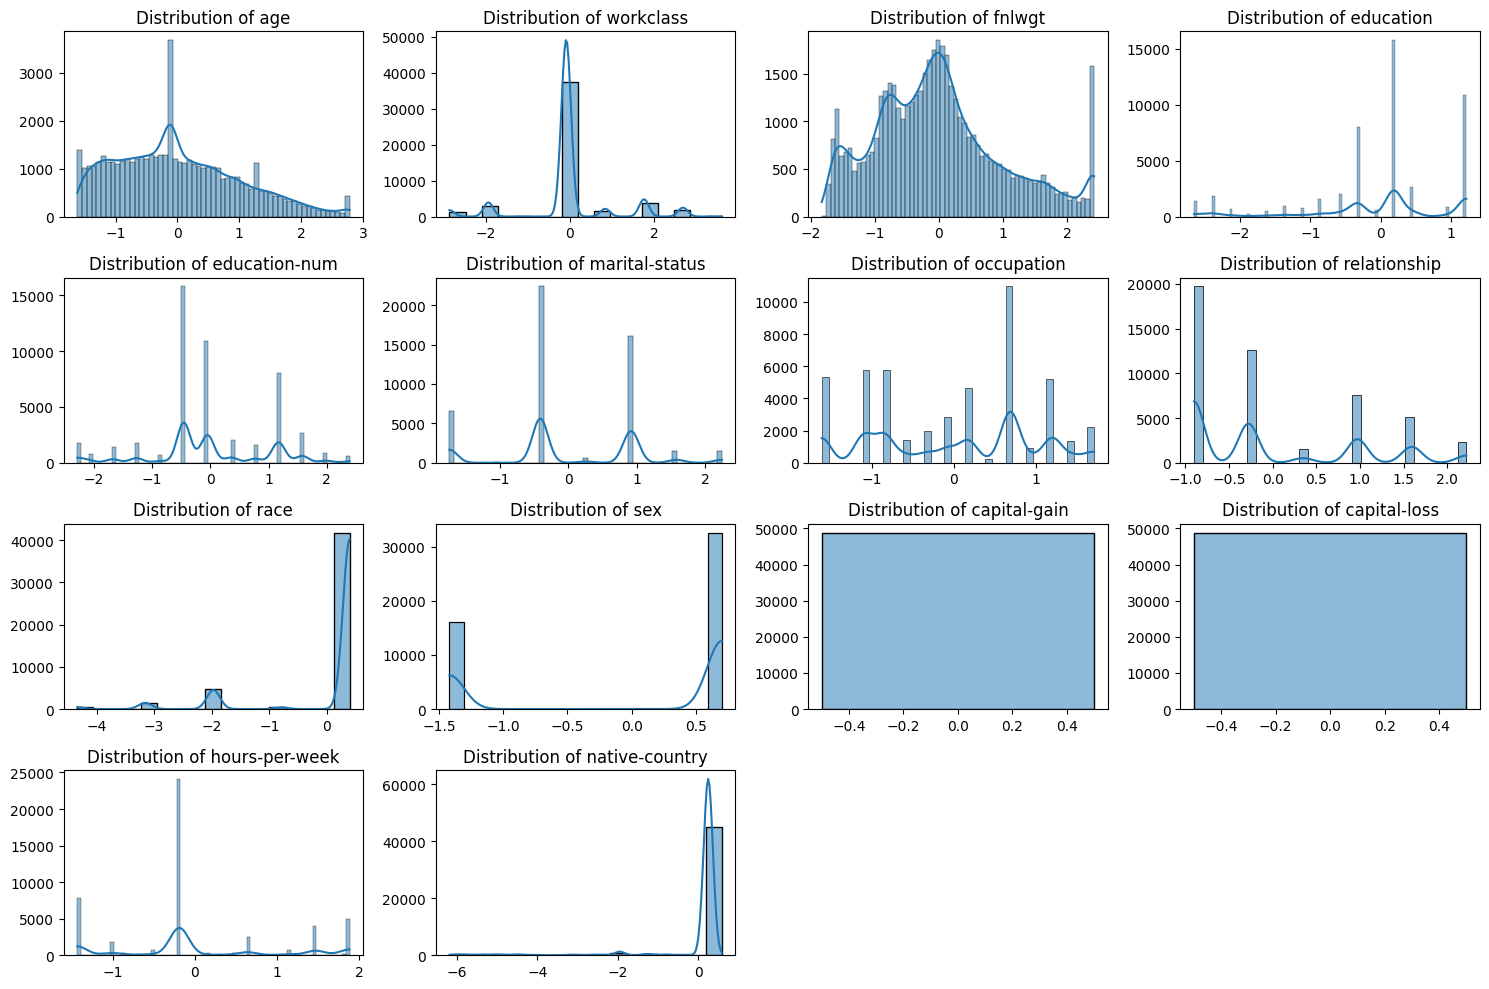

In [24]:
# Visualize distributions of scaled features
plt.figure(figsize=(15, 10))
for i, column in enumerate(adult_df_scaled.columns):
    plt.subplot(4, 4, i + 1)  # Adjust subplot grid based on number of features
    sns.histplot(adult_df_scaled[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel('') # Remove x-label to avoid clutter
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.show()

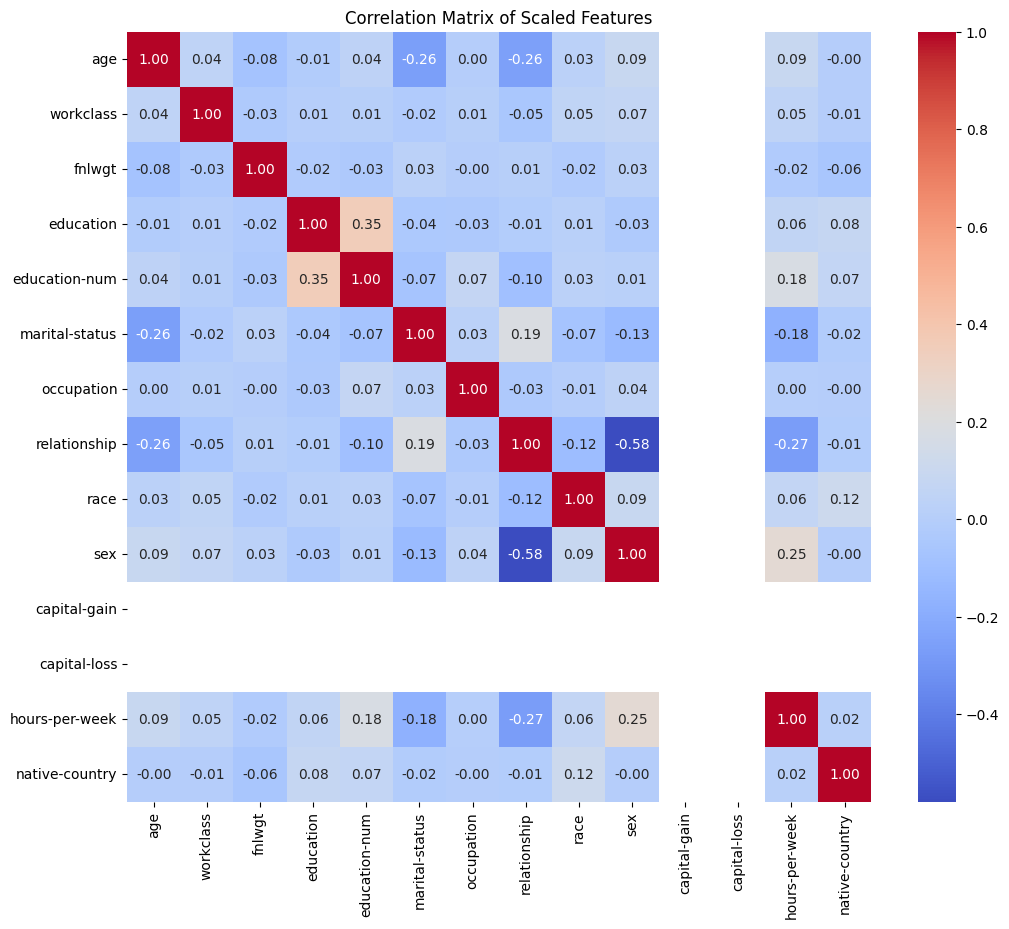

In [25]:
plt.figure(figsize=(12, 10))
sns.heatmap(adult_df_scaled.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Scaled Features')
plt.show()

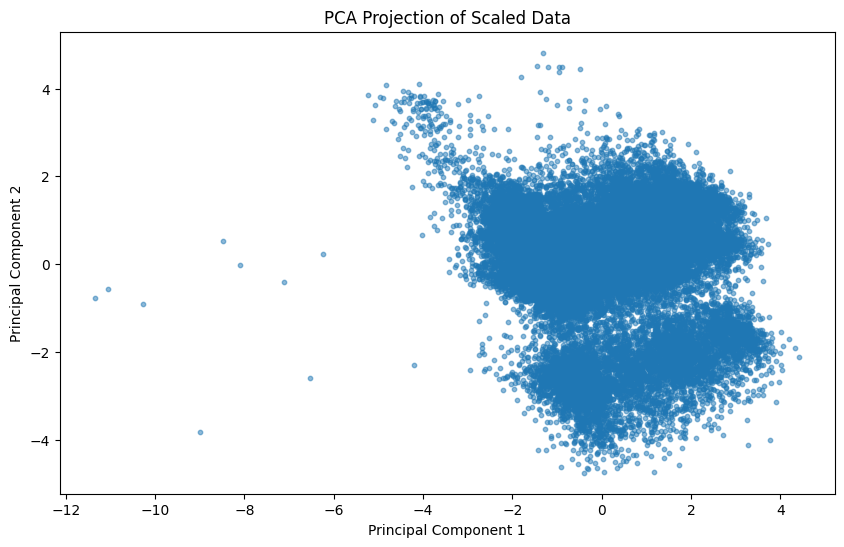

In [15]:
# 1. PCA for Visualization (2 components)

# Ensure no NaN or inf values remain in adult_df_scaled before PCA
# Replace inf with NaN first, then fill NaNs
adult_df_scaled.replace([np.inf, -np.inf], np.nan, inplace=True)
adult_df_scaled.fillna(0, inplace=True)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(adult_df_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], alpha=0.5,s=10)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Scaled Data')
plt.show()

## 3.Clustering

## Determine Optimal K for KMeans using Elbow Method



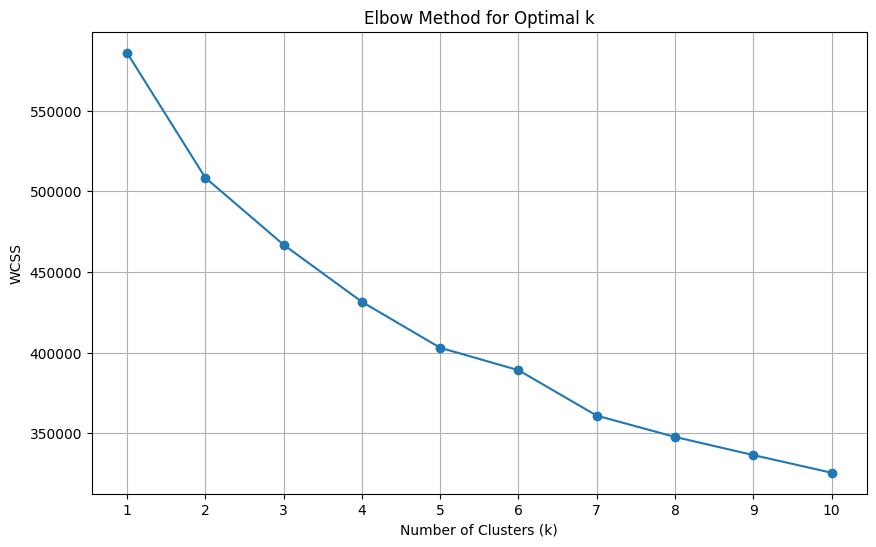

In [27]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init=10 to suppress future warning
    kmeans.fit(adult_df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

## Determine Optimal K for KMeans using Silhouette Score



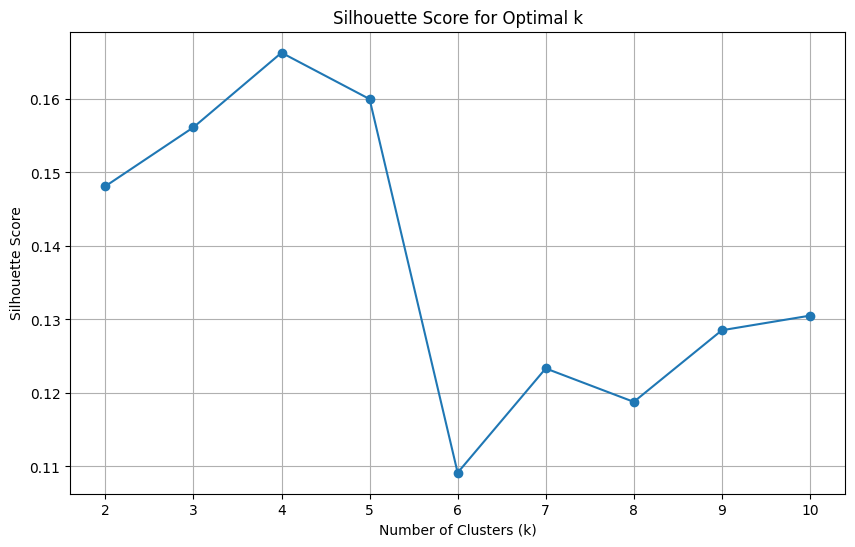

In [28]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(adult_df_scaled)
    labels = kmeans.predict(adult_df_scaled)
    score = silhouette_score(adult_df_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

## Apply K-Means Clustering with Optimal K



In [29]:
optimal_k = 4 # Based on Elbow Method and Silhouette Score
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(adult_df_scaled)

# Predict cluster labels
clusters = kmeans.predict(adult_df_scaled)

# Add cluster labels to a new DataFrame
adult_df_clustered = adult_df_scaled.copy()
adult_df_clustered['cluster'] = clusters

print(adult_df_clustered.head())

        age  workclass    fnlwgt  education  education-num  marital-status  \
0  0.035123   2.689325 -1.146152  -0.332588       1.171344        0.916280   
1  0.864064   1.763610 -1.085355  -0.332588       1.171344       -0.410262   
2 -0.040236  -0.087820  0.303009   0.183622      -0.456772       -1.736803   
3  1.090139  -0.087820  0.503130  -2.397429      -1.270830       -0.410262   
4 -0.793819  -0.087820  1.590950  -0.332588       1.171344       -0.410262   

   occupation  relationship      race       sex  capital-gain  capital-loss  \
0   -1.607341     -0.276694  0.392425  0.704165           0.0           0.0   
1   -0.841717     -0.900793  0.392425  0.704165           0.0           0.0   
2   -0.331301     -0.276694  0.392425  0.704165           0.0           0.0   
3   -0.331301     -0.900793 -1.971614  0.704165           0.0           0.0   
4    0.689531      2.219701 -1.971614 -1.420121           0.0           0.0   

   hours-per-week  native-country  cluster  
0       -0.

## Visualize K-Means Clusters with PCA



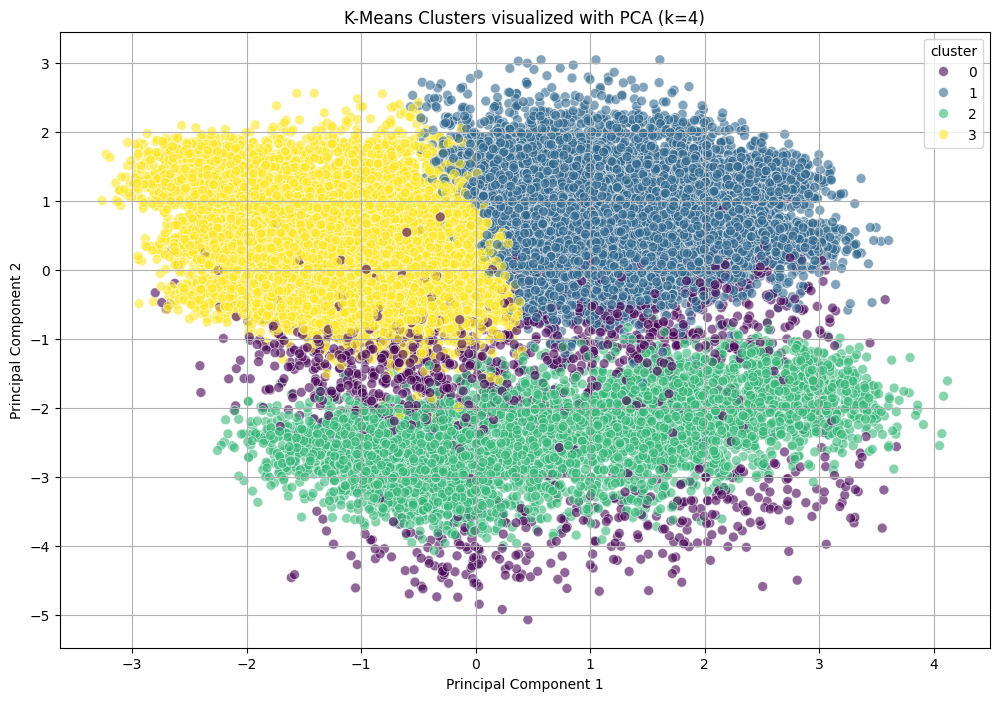

In [30]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=pca_data[:, 0],
    y=pca_data[:, 1],
    hue=adult_df_clustered['cluster'],
    palette='viridis',
    legend='full',
    alpha=0.6,
    s=50
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters visualized with PCA (k=4)')
plt.grid(True)
plt.show()

## Determine Optimal Number of Clusters using Dendrogram



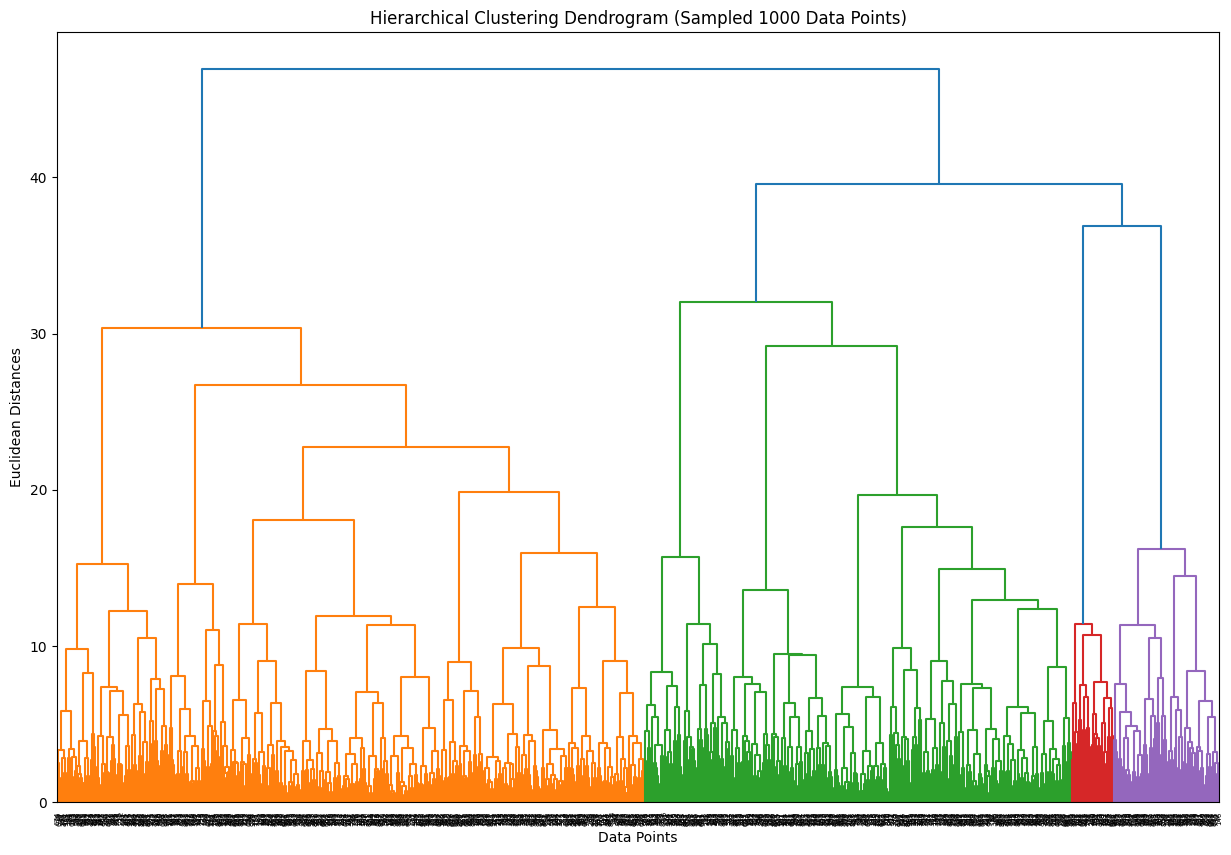

In [33]:
sample_size = 1000 # You can adjust this number based on your system's capabilities
random_sample = adult_df_scaled.sample(n=sample_size, random_state=42)

linked = linkage(random_sample, method='ward')

plt.figure(figsize=(15, 10))
dendrogram(linked)
plt.title(f'Hierarchical Clustering Dendrogram (Sampled {sample_size} Data Points)')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distances')
plt.show()

## Apply Agglomerative Clustering



In [16]:
import pandas as pd

# Removed PCA recalculation as pca_data is already defined from previous cells
# We will use the globally available pca_data and adult_df_scaled.

# Create a DataFrame from pca_data to add column names and the cluster label easily
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

# Sample the PCA data for Agglomerative Clustering to prevent crashes
sample_size_agg = 5000 # You can adjust this number
sampled_pca_df = pca_df.sample(n=sample_size_agg, random_state=42)

optimal_clusters_agg = 3 # Visually determined from the dendrogram (on a sample)

agglomerative_clustering = AgglomerativeClustering(n_clusters=optimal_clusters_agg, metric='euclidean', linkage='ward')
clusters_agg = agglomerative_clustering.fit_predict(sampled_pca_df) # Apply to sampled_pca_df

adult_df_agg_clustered = sampled_pca_df.copy() # Use sampled_pca_df as base
adult_df_agg_clustered['cluster'] = clusters_agg

print(adult_df_agg_clustered.head())

            PC1       PC2  cluster
7762   0.952469 -0.497496        0
23881  2.844221 -1.043272        2
30507  1.119854 -0.514381        0
28911  1.999832  1.475116        0
19484  1.168769 -0.200768        0


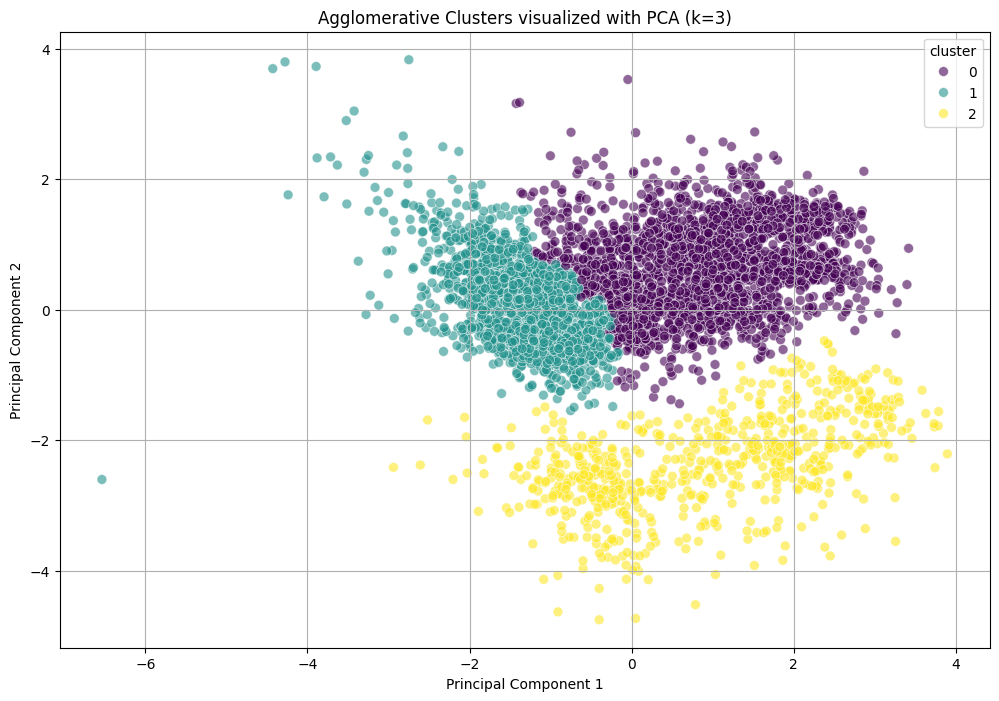

In [17]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=adult_df_agg_clustered['PC1'],
    y=adult_df_agg_clustered['PC2'],
    hue=adult_df_agg_clustered['cluster'],
    palette='viridis',
    legend='full',
    alpha=0.6,
    s=50
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Agglomerative Clusters visualized with PCA (k={optimal_clusters_agg})')
plt.grid(True)
plt.show()

## 4.Interpretation and Profiling

## Add Cluster Labels to Original DataFrame


In [23]:
#Create a new DataFrame by combining the original `adult_df` with the K-Means cluster labels (`clusters`) to allow for interpretation of features in their original, unscaled form.
# create a copy of the original adult_df. Then, I will add the K-Means cluster labels as a new column to this copied DataFrame, as the instructions specify.


adult_df_with_clusters = adult_df.copy()
adult_df_with_clusters['cluster'] = clusters

print(adult_df_with_clusters.head())

    age         workclass  fnlwgt  education  education-num  \
0  39.0         State-gov   77516  Bachelors             13   
1  50.0  Self-emp-not-inc   83311  Bachelors             13   
2  38.0           Private  215646    HS-grad              9   
3  53.0           Private  234721       11th              7   
4  28.0           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  cluster  
0          2174             0            40.0            NaN  <=50K        3  
1             0   

## Analyze Numerical Features per Cluster



In [24]:
#Calculate and display descriptive statistics (mean, median, and standard deviation) for all numerical features within each K-Means cluster. Exclude 'fnlwgt' as it is a statistical weight and not directly related to demographic or work attributes.
#calculate the mean, median, and standard deviation for numerical features (excluding 'fnlwgt') within each K-Means cluster and store them in a new DataFrame for organized display, as requested by the instructions.

numerical_features = adult_df_with_clusters.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'fnlwgt' in numerical_features:
    numerical_features.remove('fnlwgt')
if 'cluster' in numerical_features: # Remove cluster column if it's there, as it's the grouping key
    numerical_features.remove('cluster')

cluster_numerical_stats = adult_df_with_clusters.groupby('cluster')[numerical_features].agg(['mean', 'median', 'std'])

print("Descriptive statistics for numerical features within each K-Means cluster (excluding 'fnlwgt'):\n")
print(cluster_numerical_stats)

Descriptive statistics for numerical features within each K-Means cluster (excluding 'fnlwgt'):

               age                   education-num                   \
              mean median        std          mean median       std   
cluster                                                               
0        33.191302   30.0  12.873763     10.443351   10.0  1.691195   
1        41.949248   41.0  13.695261     11.009417   10.0  2.634690   
2        38.547221   36.0  17.055258      5.619743    6.0  1.703696   
3        42.275969   41.0  12.461564     10.904967   10.0  2.026678   

        capital-gain                     capital-loss                      \
                mean median          std         mean  median         std   
cluster                                                                     
0         464.826392    0.0  4212.129792     1.276404     0.0   30.684623   
1           0.000000    0.0     0.000000  1900.473991  1902.0  314.990247   
2         271.470787

In [25]:
#To understand the characteristics of each cluster regarding categorical features, I will identify the most frequent value (mode) for each categorical column within each K-Means cluster, as specified in the main task instructions.

categorical_features_for_analysis = adult_df_with_clusters.select_dtypes(include=['object']).columns.tolist()
# Exclude 'income' if it's considered a target variable or not relevant for cluster profiling based on other features.
# For now, let's keep it as it's a categorical feature that can help describe clusters.

print("Most frequent values for categorical features within each K-Means cluster:\n")
for feature in categorical_features_for_analysis:
    print(f"Feature: {feature}")
    mode_per_cluster = adult_df_with_clusters.groupby('cluster')[feature].agg(lambda x: x.mode()[0] if not x.mode().empty else 'No mode')
    print(mode_per_cluster)
    print("\n")

Most frequent values for categorical features within each K-Means cluster:

Feature: workclass
cluster
0    Private
1    Private
2    Private
3    Private
Name: workclass, dtype: object


Feature: education
cluster
0    HS-grad
1    HS-grad
2       11th
3    HS-grad
Name: education, dtype: object


Feature: marital-status
cluster
0         Never-married
1    Married-civ-spouse
2    Married-civ-spouse
3    Married-civ-spouse
Name: marital-status, dtype: object


Feature: occupation
cluster
0       Adm-clerical
1    Exec-managerial
2      Other-service
3       Craft-repair
Name: occupation, dtype: object


Feature: relationship
cluster
0    Own-child
1      Husband
2      Husband
3      Husband
Name: relationship, dtype: object


Feature: race
cluster
0    White
1    White
2    White
3    White
Name: race, dtype: object


Feature: sex
cluster
0    Female
1      Male
2      Male
3      Male
Name: sex, dtype: object


Feature: native-country
cluster
0    United-States
1    United-States
2 

### Income Distribution per Cluster

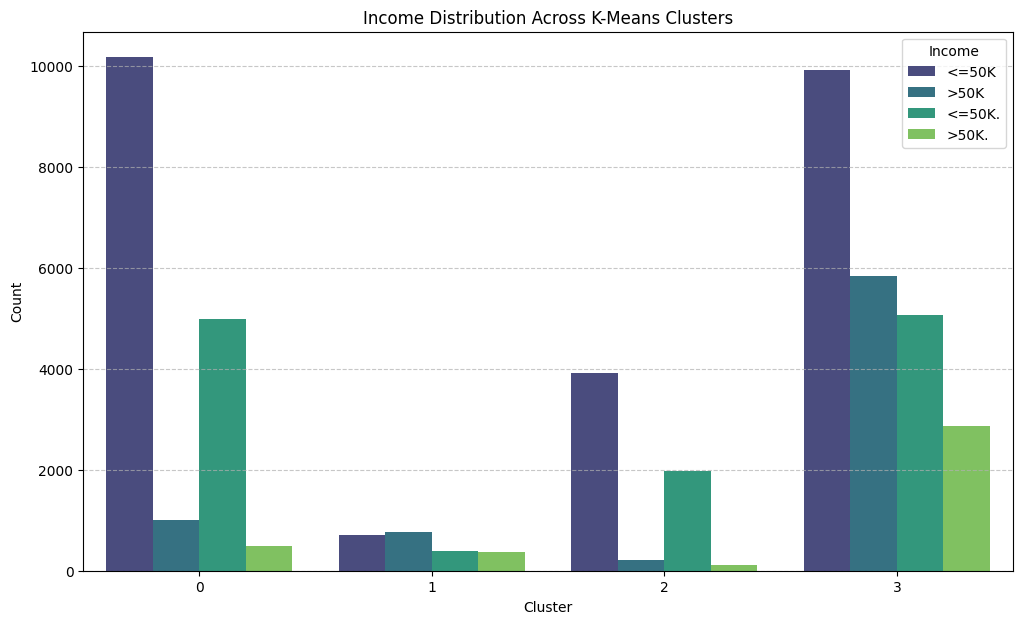

In [26]:
plt.figure(figsize=(12, 7))
sns.countplot(data=adult_df_with_clusters, x='cluster', hue='income', palette='viridis')
plt.title('Income Distribution Across K-Means Clusters')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Income')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This plot helps to visualize the income distribution within each cluster. For instance, some clusters might have a higher proportion of individuals earning `>50K`, while others are predominantly `&lt;=50K`.